# Campus Water Infrastructure Data Analysis and Predictive Modelling

## Project Overview

This notebook analyses historical campus water data to understand water usage and pressure patterns. It also uses machine learning models to predict the next day's water volume and pressure. Finally, it checks the health of the water meters using historical sensor data.

### Objectives

This project aims to:

- Load and prepare the water data.
- Combine the water volume and pressure datasets.
- Create new features for the machine learning models.
- Train models to predict the next day's water volume and pressure.
- Measure how well the models perform.
- Check the health of the water meters using historical sensor data.

## Import Libraries
The Python libraries used in this project are imported. These libraries are used to load and analyse the data, build the machine learning models, measure model performance, and create graphs.

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

## Set Project Paths
The file paths for the water volume and pressure data are set. This allows the notebook to find and load the data from the correct folders.

In [2]:
home = os.path.expanduser("~/Downloads/water_dataa")
volume_path = os.path.join(home, "volume")
pressure_path = os.path.join(home, "pressure")

## Load and Combine All CSV Files
The water volume and pressure data are stored in multiple CSV files. This section loads all of the files, keeps track of where each file came from, and combines them into one water volume dataset and one water pressure dataset.

In [3]:
vol_files = [f for f in os.listdir(volume_path) if f.endswith('.csv')]
volume_dfs = []
for f in vol_files:
    df = pd.read_csv(os.path.join(volume_path, f))
    df["__source_file"] = f
    volume_dfs.append(df)
volume_df = pd.concat(volume_dfs, ignore_index=True)


# Load pressure
pres_files = [f for f in os.listdir(pressure_path) if f.endswith('.csv')]
pressure_dfs = []
for f in pres_files:
    df = pd.read_csv(os.path.join(pressure_path, f))
    df["__source_file"] = f
    pressure_dfs.append(df)
pressure_df = pd.concat(pressure_dfs, ignore_index=True)

print("Loading CSV files...")
print("Found volume files:", len(vol_files))
print("Found pressure files:", len(pres_files))

Loading CSV files...
Found volume files: 545
Found pressure files: 395


## Clean Columns and Convert Dates
The column names are cleaned by removing extra spaces. The **Date Time** column is then converted to the correct date and time format. Any rows with missing or invalid dates are removed before the data is analysed.

In [4]:
volume_df.columns = volume_df.columns.str.strip()
pres_columns = pressure_df.columns = pressure_df.columns.str.strip()


volume_df['Date Time'] = pd.to_datetime(volume_df['Date Time'], errors='coerce')
pressure_df['Date Time'] = pd.to_datetime(pressure_df['Date Time'], errors='coerce')


# Drop rows missing Date Time (bad timestamps)
volume_df = volume_df.dropna(subset=['Date Time'])
pressure_df = pressure_df.dropna(subset=['Date Time'])

print("Cleaning column names and fixing Date Time...")
print("Volume columns:", list(volume_df.columns))
print("Pressure columns:", list(pressure_df.columns))

Cleaning column names and fixing Date Time...
Volume columns: ['Date Time', 'Amonitas Combination Meter', 'Art Building Combination Meter', 'FNB Stadium Combination Meter', 'Park Road Gate Combination Meter', '__source_file', 'ETB Combination Meter', 'Gate 19 Combination Meter', 'Library Combination Meter', 'Mannheim Ladies', 'Orion Combination Meter', 'Ya Rona Combination Meter', 'ZR Combination Meter']
Pressure columns: ['Date Time', 'CUT Maintenance Center', 'Technikon Residence', '__source_file']


## Resample to Daily Level
The data is grouped into daily values using the **Date Time** column. Daily water volume is calculated by adding all readings for each day, while daily water pressure is calculated by finding the average reading for each day.

In [5]:
# Convert Date Time to index
volume_df = volume_df.set_index('Date Time')
pressure_df = pressure_df.set_index('Date Time')


# Get only the meter columns (exclude __source_file)
vol_meters = [col for col in volume_df.columns if col != "__source_file"]
pres_meters = [col for col in pressure_df.columns if col != "__source_file"]


# Daily volume = sum
vol_daily = volume_df[vol_meters].resample('D').sum()


# Daily pressure = mean
pres_daily = pressure_df[pres_meters].resample('D').mean()

print("Resampling to daily totals (volume) and averages (pressure)...")

Resampling to daily totals (volume) and averages (pressure)...


## Build Total Volume and Total Pressure
New columns are created for the total daily water volume and the average daily water pressure. These values are calculated from the daily meter readings and are used in the later analysis.

In [6]:

# Make copies to avoid SettingWithCopyWarning
vol_daily = vol_daily.copy()
pres_daily = pres_daily.copy()

# Compute totals
vol_daily['Total_Volume'] = vol_daily.sum(axis=1)
pres_daily['Total_Pressure'] = pres_daily.mean(axis=1)

# Print sample
print("Sample Total_Volume:")
print(vol_daily[['Total_Volume']].head())
print("\nSample Total_Pressure:")
print(pres_daily[['Total_Pressure']].head())


Sample Total_Volume:
            Total_Volume
Date Time               
2023-07-06      5.437500
2023-07-07     45.445556
2023-07-08     51.500556
2023-07-09     53.178889
2023-07-10     58.107778

Sample Total_Pressure:
            Total_Pressure
Date Time                 
2024-04-01       33.004225
2024-04-02       27.909578
2024-04-03       31.762942
2024-04-04       36.897266
2024-04-05       35.935015


## Merge Volume and Pressure 
The daily water volume and pressure data are combined into a single dataset. This makes it easier to analyse both sets of data together and prepare them for the next steps.

In [7]:

merged = vol_daily.join(pres_daily, how='inner', lsuffix='_vol', rsuffix='_pres')

# Print sample
print("Merged DataFrame (Volume + Pressure):")
print(merged[['Total_Volume','Total_Pressure']].head())


Merged DataFrame (Volume + Pressure):
            Total_Volume  Total_Pressure
Date Time                               
2024-04-01    111.361111       33.004225
2024-04-02    109.277778       27.909578
2024-04-03    102.444444       31.762942
2024-04-04    104.577778       36.897266
2024-04-05    106.927778       35.935015


## Create Time Features
New columns are created from the date and time information. These columns store the year, month, day, day of the week, and hour, and are added to the dataset for later analysis and model training.

In [8]:

merged['year'] = merged.index.year
merged['month'] = merged.index.month
merged['day'] = merged.index.day
merged['dayofweek'] = merged.index.dayofweek
merged['hour'] = merged.index.hour  # will be 0 if data is daily

print("Merged DataFrame with time features:")
print(merged[['year', 'month', 'day', 'dayofweek', 'hour']].head())



Merged DataFrame with time features:
            year  month  day  dayofweek  hour
Date Time                                    
2024-04-01  2024      4    1          0     0
2024-04-02  2024      4    2          1     0
2024-04-03  2024      4    3          2     0
2024-04-04  2024      4    4          3     0
2024-04-05  2024      4    5          4     0


## Create Prediction Targets
The models are trained to predict the next day's total water volume and total water pressure. These next-day values are created as the prediction targets. The last row is then removed because there is no data for the following day.

In [9]:

merged['target_volume'] = merged['Total_Volume'].shift(-1)
merged['target_pressure'] = merged['Total_Pressure'].shift(-1)

# Drop last row which has no target
merged = merged.dropna(subset=['target_volume', 'target_pressure'])

print("Merged DataFrame with next-day targets:")
print(merged[['Total_Volume', 'Total_Pressure', 'target_volume', 'target_pressure']].head())





Merged DataFrame with next-day targets:
            Total_Volume  Total_Pressure  target_volume  target_pressure
Date Time                                                               
2024-04-01    111.361111       33.004225     109.277778        27.909578
2024-04-02    109.277778       27.909578     102.444444        31.762942
2024-04-03    102.444444       31.762942     104.577778        36.897266
2024-04-04    104.577778       36.897266     106.927778        35.935015
2024-04-05    106.927778       35.935015      93.300000        36.889811


## Check the Dataset Columns
This section displays the names of all the columns in the dataset. It is used to check that the required columns have been created before continuing.

In [10]:
print(merged.columns)


Index(['Amonitas Combination Meter', 'Art Building Combination Meter',
       'FNB Stadium Combination Meter', 'Park Road Gate Combination Meter',
       'ETB Combination Meter', 'Gate 19 Combination Meter',
       'Library Combination Meter', 'Mannheim Ladies',
       'Orion Combination Meter', 'Ya Rona Combination Meter',
       'ZR Combination Meter', 'Total_Volume', 'CUT Maintenance Center',
       'Technikon Residence', 'Total_Pressure', 'year', 'month', 'day',
       'dayofweek', 'hour', 'target_volume', 'target_pressure'],
      dtype='object')


## Check and Convert Data Types
This section checks the data in the pressure dataset and converts the values to a numeric format where needed. This helps make sure the data is ready for analysis.

In [11]:
# Check first rows of pressure_df
print(pressure_df.head())

# Check data types
print(pressure_df.dtypes)

# Check numeric conversion
pressure_df = pressure_df.apply(pd.to_numeric, errors='coerce')
print(pressure_df.head())


                     CUT Maintenance Center  Technikon Residence  \
Date Time                                                          
2025-03-04 00:00:00               43.744449            60.017594   
2025-03-04 01:00:00               44.221852            57.329617   
2025-03-04 02:00:00               44.647359            61.543199   
2025-03-04 03:00:00               44.512441            61.273363   
2025-03-04 04:00:00               44.886059            59.529812   

                          __source_file  
Date Time                                
2025-03-04 00:00:00  2024-03-04.csv.csv  
2025-03-04 01:00:00  2024-03-04.csv.csv  
2025-03-04 02:00:00  2024-03-04.csv.csv  
2025-03-04 03:00:00  2024-03-04.csv.csv  
2025-03-04 04:00:00  2024-03-04.csv.csv  
CUT Maintenance Center    float64
Technikon Residence       float64
__source_file              object
dtype: object
                     CUT Maintenance Center  Technikon Residence  \
Date Time                                    

## Create Lag and Rolling Features
This section creates new columns using previous water volume and pressure values. It also creates rolling averages, which are the average water volume and pressure over the previous 3 days and 7 days. These features give the models more information about recent changes in the data. Rows with missing values created during these calculations are then removed.

In [12]:

# Lags
merged['lag1_volume'] = merged['Total_Volume'].shift(1)
merged['lag7_volume'] = merged['Total_Volume'].shift(7)
merged['lag1_pressure'] = merged['Total_Pressure'].shift(1)
merged['lag7_pressure'] = merged['Total_Pressure'].shift(7)

# Rolling windows
merged['roll3_volume'] = merged['Total_Volume'].rolling(3).mean()
merged['roll7_volume'] = merged['Total_Volume'].rolling(7).mean()
merged['roll3_pressure'] = merged['Total_Pressure'].rolling(3).mean()
merged['roll7_pressure'] = merged['Total_Pressure'].rolling(7).mean()

# Drop NaNs created by lags/rolling
merged = merged.dropna()

print("Merged DataFrame with lags and rolling features:")
print(merged.head())



Merged DataFrame with lags and rolling features:
            Amonitas Combination Meter  Art Building Combination Meter  \
Date Time                                                                
2024-04-08                         0.0                             0.0   
2024-04-09                         0.0                             0.0   
2024-04-10                         0.0                             0.0   
2024-04-11                         0.0                             0.0   
2024-04-12                         0.0                             0.0   

            FNB Stadium Combination Meter  Park Road Gate Combination Meter  \
Date Time                                                                     
2024-04-08                       4.055556                         85.861111   
2024-04-09                       3.288889                         93.472222   
2024-04-10                       3.544444                         94.022222   
2024-04-11                       4.18

## Define Features and Targets
The data is divided into two groups. The first group contains the information (features) that the models use to make predictions. The second group contains the next day's total water volume and total water pressure (targets) that the models are trained to predict.

In [13]:

features = [
    'Total_Pressure', 'year', 'month', 'day', 'dayofweek', 'hour',
    'lag1_volume', 'lag7_volume', 'roll3_volume', 'roll7_volume',
    'lag1_pressure', 'lag7_pressure', 'roll3_pressure', 'roll7_pressure'
]

X = merged[features]
y_volume = merged['target_volume']
y_pressure = merged['target_pressure']

print("Features preview:")
print(X.head())
print("\nTarget Volume preview:")
print(y_volume.head())
print("\nTarget Pressure preview:")
print(y_pressure.head())



Features preview:
            Total_Pressure  year  month  day  dayofweek  hour  lag1_volume  \
Date Time                                                                    
2024-04-08       35.894041  2024      4    8          0     0   103.122222   
2024-04-09       35.857241  2024      4    9          1     0   100.733333   
2024-04-10       35.678925  2024      4   10          2     0   106.622222   
2024-04-11       35.710613  2024      4   11          3     0   108.022222   
2024-04-12       34.953340  2024      4   12          4     0   109.105556   

            lag7_volume  roll3_volume  roll7_volume  lag1_pressure  \
Date Time                                                            
2024-04-08   111.361111     99.051852    102.911905      36.608841   
2024-04-09   109.277778    103.492593    102.532540      35.894041   
2024-04-10   102.444444    105.125926    103.329365      35.857241   
2024-04-11   104.577778    107.916667    103.976190      35.678925   
2024-04-12   10

## Train Random Forest Model for Volume
A Random Forest model is trained to predict the next day's total water volume. The data is divided into training data and testing data. After the model is trained, it is tested using the testing data. Its performance is measured using MAE and RMSE. FFinally, the model shows which input columns had the biggest effect on its predictions.

In [14]:

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X, y_volume, shuffle=False, test_size=0.2
)

rf_volume = RandomForestRegressor(n_estimators=400, max_depth=15, random_state=42)
rf_volume.fit(X_train_v, y_train_v)

rf_volume_pred = rf_volume.predict(X_test_v)

mae_v = mean_absolute_error(y_test_v, rf_volume_pred)
rmse_v = np.sqrt(mean_squared_error(y_test_v, rf_volume_pred))

print(f"Random Forest (Volume) MAE: {mae_v:.2f}")
print(f"Random Forest (Volume) RMSE: {rmse_v:.2f}")

# Feature importance for Volume
importances_v = rf_volume.feature_importances_
print("\nFeature importance (Volume):")
for feat, imp in zip(features, importances_v):
    print(f"{feat}: {imp:.4f}")


Random Forest (Volume) MAE: 1263.01
Random Forest (Volume) RMSE: 4344.10

Feature importance (Volume):
Total_Pressure: 0.0538
year: 0.0000
month: 0.0349
day: 0.1211
dayofweek: 0.0505
hour: 0.0000
lag1_volume: 0.0502
lag7_volume: 0.1203
roll3_volume: 0.2243
roll7_volume: 0.1024
lag1_pressure: 0.0844
lag7_pressure: 0.0547
roll3_pressure: 0.0636
roll7_pressure: 0.0398


## Train Random Forest Model for Pressure
A Random Forest model is trained to predict the next day's total water pressure. The data is divided into training data and testing data. After the model is trained, it is tested using the testing data. Its performance is measured using MAE and RMSE. Finally, the model shows which input columns had the biggest effect on its predictions.

In [15]:

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_pressure, shuffle=False, test_size=0.2
)

rf_pressure = RandomForestRegressor(n_estimators=400, max_depth=15, random_state=42)
rf_pressure.fit(X_train_p, y_train_p)

rf_pressure_pred = rf_pressure.predict(X_test_p)

mae_p = mean_absolute_error(y_test_p, rf_pressure_pred)
rmse_p = np.sqrt(mean_squared_error(y_test_p, rf_pressure_pred))

print(f"Random Forest (Pressure) MAE: {mae_p:.2f}")
print(f"Random Forest (Pressure) RMSE: {rmse_p:.2f}")

# Feature importance for Pressure
features = X.columns  # Make sure features match your training DataFrame
importances_p = rf_pressure.feature_importances_
print("\nFeature importance (Pressure):")
for feat, imp in zip(features, importances_p):
    print(f"{feat}: {imp:.4f}")




Random Forest (Pressure) MAE: 4.41
Random Forest (Pressure) RMSE: 5.48

Feature importance (Pressure):
Total_Pressure: 0.4682
year: 0.0000
month: 0.0238
day: 0.0201
dayofweek: 0.0122
hour: 0.0000
lag1_volume: 0.0192
lag7_volume: 0.0170
roll3_volume: 0.0140
roll7_volume: 0.0181
lag1_pressure: 0.0725
lag7_pressure: 0.0424
roll3_pressure: 0.2033
roll7_pressure: 0.0892


## Plot Feature Importance for Each Model
This section displays a chart for each Random Forest model. The charts show which input columns had the biggest effect on the model's predictions for water volume and water pressure.

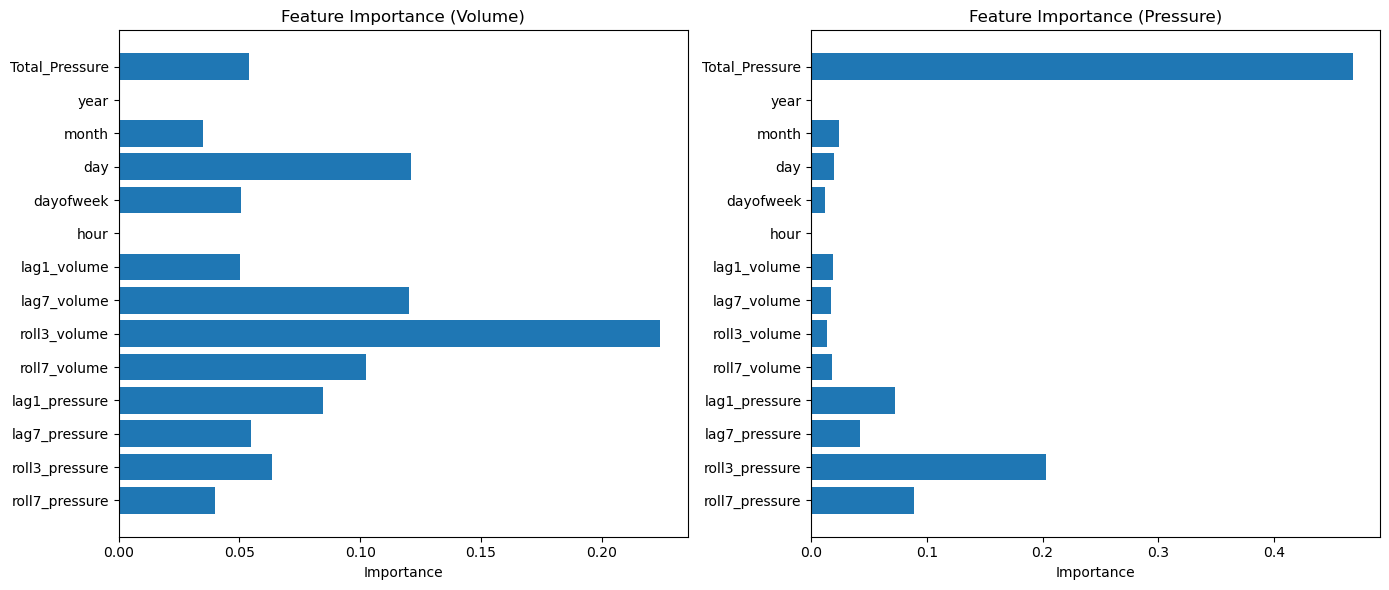

In [16]:

plt.figure(figsize=(14,6))

# Volume
plt.subplot(1,2,1)
plt.barh(features, importances_v)
plt.xlabel("Importance")
plt.title("Feature Importance (Volume)")
plt.gca().invert_yaxis()

# Pressure
plt.subplot(1,2,2)
plt.barh(features, importances_p)
plt.xlabel("Importance")
plt.title("Feature Importance (Pressure)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## Compare Feature Importance
This section compares the input columns used by the two Random Forest models. The chart shows whether the same input columns or different input columns had the biggest effect on predicting water volume and water pressure.

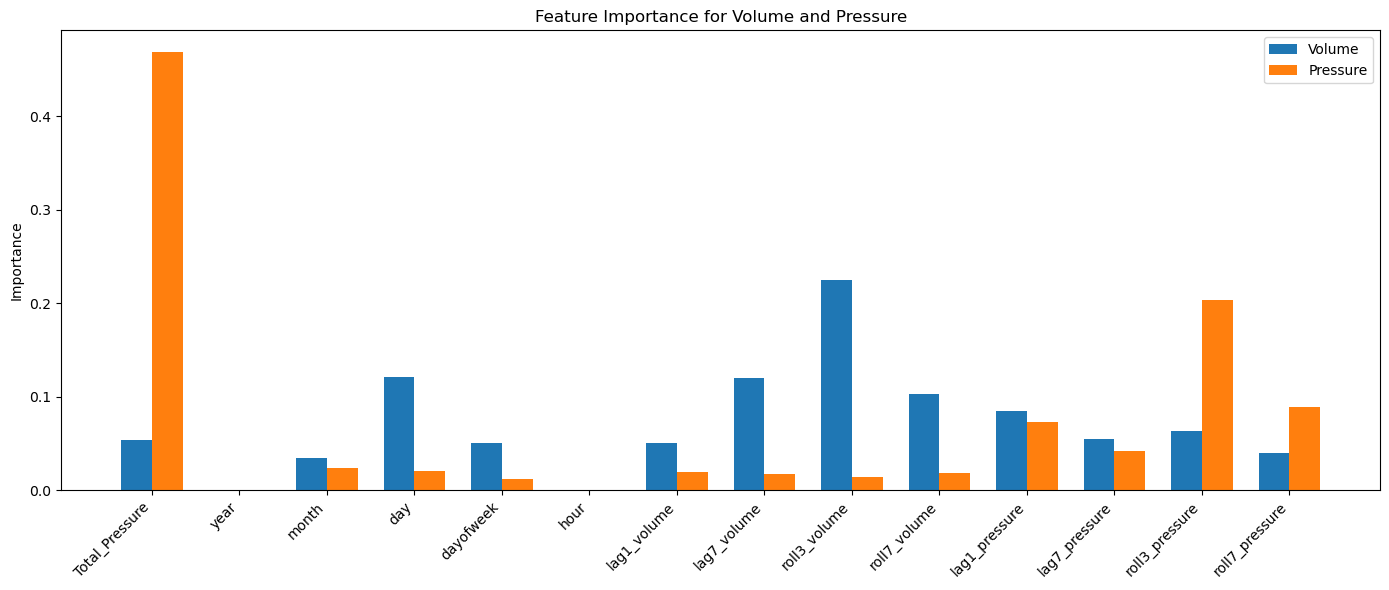

In [17]:

x = np.arange(len(features))  # the label locations
width = 0.35  # width of the bars

plt.figure(figsize=(14,6))

# Plot Volume importance
plt.bar(x - width/2, importances_v, width, label='Volume')

# Plot Pressure importance
plt.bar(x + width/2, importances_p, width, label='Pressure')

# Labels & ticks
plt.xticks(x, features, rotation=45, ha='right')
plt.ylabel("Importance")
plt.title("Feature Importance for Volume and Pressure")
plt.legend()
plt.tight_layout()
plt.show()



## Feature Importance
This section displays the feature importance values for the Random Forest pressure model. These values show how much each input column contributed to the model's predictions. The exact values are printed to support the charts shown earlier.

In [18]:

# Feature importance for your trained model
features = X.columns  # or X_train_p.columns
importances = rf_pressure.feature_importances_  # use the correct model name

for feat, imp in zip(features, importances):
    print(f"{feat}: {imp:.4f}")



Total_Pressure: 0.4682
year: 0.0000
month: 0.0238
day: 0.0201
dayofweek: 0.0122
hour: 0.0000
lag1_volume: 0.0192
lag7_volume: 0.0170
roll3_volume: 0.0140
roll7_volume: 0.0181
lag1_pressure: 0.0725
lag7_pressure: 0.0424
roll3_pressure: 0.2033
roll7_pressure: 0.0892


## Plot Actual vs Predicted Water Volume
This chart compares the actual daily water volume with the values predicted by the Random Forest model. It shows how closely the predicted values match the actual values.

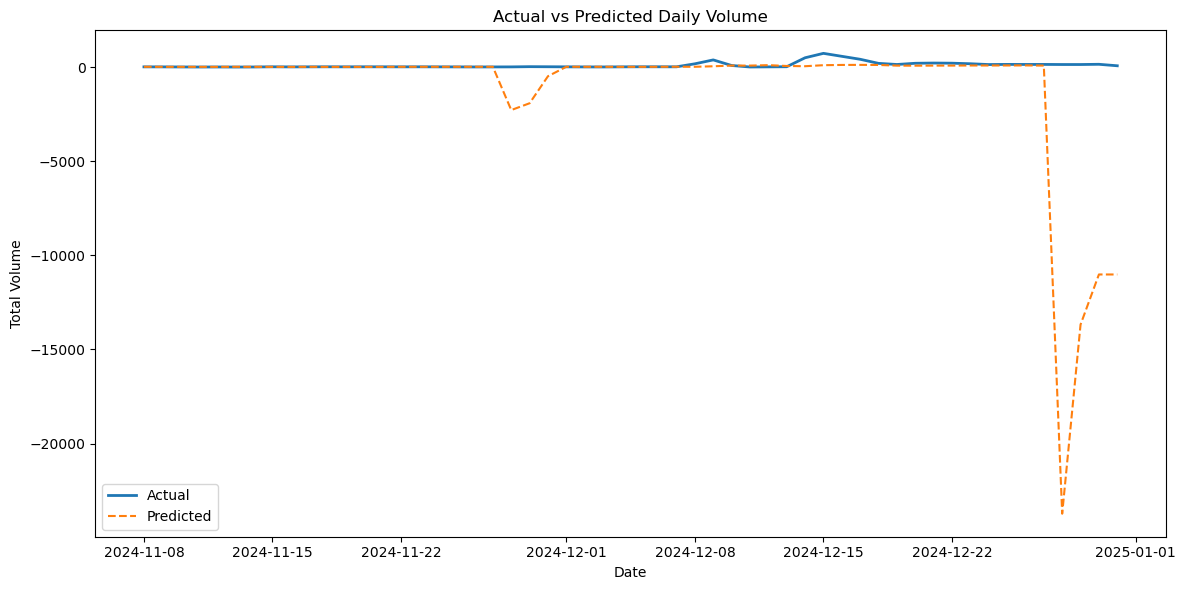

In [19]:
# ===== PLOT ACTUAL vs PREDICTED VOLUME =====
plt.figure(figsize=(12,6))

# Use the correct test & prediction variables
plt.plot(y_test_v.index, y_test_v.values, label='Actual', linewidth=2)
plt.plot(y_test_v.index, rf_volume_pred, label='Predicted', linestyle='--')

plt.title('Actual vs Predicted Daily Volume')
plt.xlabel('Date')
plt.ylabel('Total Volume')
plt.legend()
plt.tight_layout()
plt.show()



## Check for Water Meters That Always Read Zero
This section checks whether any water meters recorded a value of zero for every day in the dataset. Meters that always read zero may be inactive or not collecting data correctly.

In [20]:
always_zero = (vol_daily[vol_meters].sum() == 0)
print("Meters that always read 0:")
print(always_zero[always_zero].index.tolist())


Meters that always read 0:
['Art Building Combination Meter', 'Library Combination Meter']


## Check Which Meters Sometimes Read Zero
This section checks which water meters recorded a value of zero on some days but not on every day. These meters may need further investigation to determine whether the zero readings are expected or caused by missing data or sensor problems.

In [21]:
sometimes_zero = (vol_daily[vol_meters] == 0).any() & (vol_daily[vol_meters].sum() != 0)
print("Meters that sometimes read 0:")
print(sometimes_zero[sometimes_zero].index.tolist())


Meters that sometimes read 0:
['Amonitas Combination Meter', 'FNB Stadium Combination Meter', 'Park Road Gate Combination Meter', 'ETB Combination Meter', 'Gate 19 Combination Meter', 'Mannheim Ladies', 'Orion Combination Meter', 'Ya Rona Combination Meter', 'ZR Combination Meter']


## Identify Active and Always-Zero Water Meters
This chart shows the status of each water meter based on its readings. Green bars represent meters that recorded at least one non-zero value, even if they sometimes recorded zero. Red bars represent meters that only recorded zero values throughout the dataset.

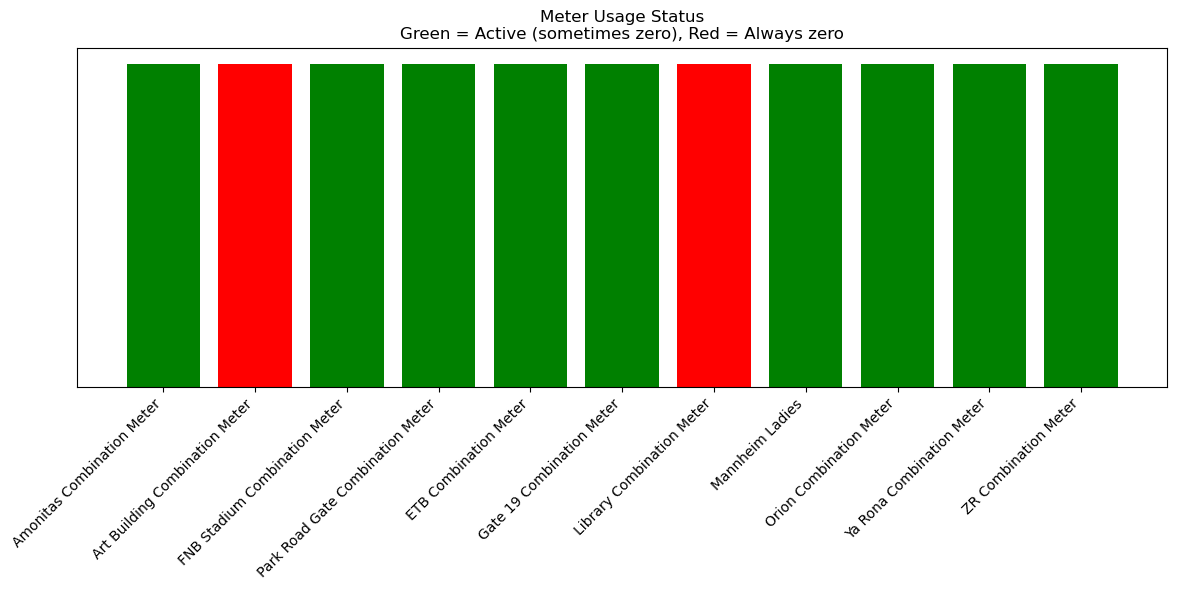

In [22]:

# Determine always-zero and active meters
always_zero = (vol_daily[vol_meters].sum() == 0)
sometimes_zero = (vol_daily[vol_meters] == 0).any() & (vol_daily[vol_meters].sum() != 0)
active_meters = ~always_zero

# Prepare labels and colors
labels = vol_meters
colors = ['red' if always_zero[m] else 'green' for m in vol_meters]

# Plot
plt.figure(figsize=(12,6))
plt.bar(labels, [1]*len(labels), color=colors)
plt.xticks(rotation=45, ha='right')
plt.yticks([])
plt.title("Meter Usage Status\nGreen = Active (sometimes zero), Red = Always zero")
plt.tight_layout()
plt.show()


## Sensor Health Check
This section checks the condition of each water meter based on how often it records zero values. Meters with no non-zero readings are classified as inactive (dead sensors). Meters with more than 40% zero readings are classified as partially active, and the remaining meters are classified as active. A sensor health report and summary are then displayed.

In [23]:

print("Running sensor health diagnostics...\n")

# Identify volume meter columns (exclude totals & features)
exclude_cols = [
    'Total_Volume', 'Total_Pressure', 'target_volume', 'target_pressure',
    'lag1_volume', 'lag7_volume', 'lag1_pressure', 'lag7_pressure',
    'roll3_volume', 'roll7_volume', 'roll3_pressure', 'roll7_pressure',
    'dayofweek', 'month'
]

meter_cols = [c for c in merged.columns if c not in exclude_cols]

results = []

for meter in meter_cols:
    series = merged[meter]
    total_days = len(series)
    zero_days = (series == 0).sum()
    nonzero_days = (series > 0).sum()
    zero_ratio = zero_days / total_days

    # Classify meter health
    if nonzero_days == 0:
        status = "INACTIVE (Dead Sensor)"
    elif zero_ratio > 0.4:
        status = "PARTIALLY ACTIVE (Unreliable)"
    else:
        status = "ACTIVE (Healthy)"

    results.append({
        "Meter": meter,
        "Total Days": total_days,
        "Zero Days": zero_days,
        "Non-Zero Days": nonzero_days,
        "Zero Ratio": round(zero_ratio, 2),
        "Status": status
    })

health_df = pd.DataFrame(results).sort_values("Zero Ratio", ascending=False)

print("Sensor Health Report:")
display(health_df)

# Summary Counts

summary = health_df["Status"].value_counts()
print("\nSensor Status Summary:")
print(summary)


Running sensor health diagnostics...

Sensor Health Report:


,Meter,Total Days,Zero Days,Non-Zero Days,Zero Ratio,Status
0,Amonitas Combination Meter,268,268,0,1.00,INACTIVE (Dead Sensor)
1,Art Building Combination Meter,268,268,0,1.00,INACTIVE (Dead Sensor)
6,Library Combination Meter,268,268,0,1.00,INACTIVE (Dead Sensor)
7,Mannheim Ladies,268,268,0,1.00,INACTIVE (Dead Sensor)
15,hour,268,268,0,1.00,INACTIVE (Dead Sensor)
9,Ya Rona Combination Meter,268,268,0,1.00,INACTIVE (Dead Sensor)
4,ETB Combination Meter,268,231,37,0.86,PARTIALLY ACTIVE (Unreliable)
5,Gate 19 Combination Meter,268,207,61,0.77,PARTIALLY ACTIVE (Unreliable)
8,Orion Combination Meter,268,47,221,0.18,ACTIVE (Healthy)
3,Park Road Gate Combination Meter,268,33,233,0.12,ACTIVE (Healthy)



Sensor Status Summary:
Status
ACTIVE (Healthy)                 8
INACTIVE (Dead Sensor)           6
PARTIALLY ACTIVE (Unreliable)    2
Name: count, dtype: int64
